# Ελένη Λαζαρίδου ΑΕΜ:10859
# Αλέξανδρος Σουρουλλάς ΑΕΜ:10819

## Task A (1/2)

In [2]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#load data
data = np.loadtxt('dataset1.csv', delimiter=',')
X = data[:, :2]  #features
y = data[:, 2]   #labels

class0 = X[y == 0]
class1 = X[y == 1]
class2 = X[y == 2]

#MLE method to calculate distribution parameters
def mle_params_estimation(data):
    #calculate mean
    mean = np.sum(data, axis=0) / len(data)

    #calculate SINDIAKIMANSI
    diff = data - mean
    cov = (diff.T @ diff) / len(data)

    return mean, cov

mean0, cov0 = mle_params_estimation(class0)
mean1, cov1 = mle_params_estimation(class1)
mean2, cov2 = mle_params_estimation(class2)


print("parameter estimation with MLE")

# Class 0
mean0, cov0 = mle_params_estimation(class0)
print(f"\nClass 0:")
print(f"  Mean: {mean0}")
print(f"  Covariance:\n{cov0}")

# Class 1
mean1, cov1 = mle_params_estimation(class1)
print(f"\nClass 1:")
print(f"  Mean: {mean1}")
print(f"  Covariance:\n{cov1}")

# Class 2
mean2, cov2 = mle_params_estimation(class2)
print(f"\nClass 2:")
print(f"  Mean: {mean2}")
print(f"  Covariance:\n{cov2}")

#pdf fuction 2 variables
def manual_bivariate_normal(x, y, mean, cov):

    point = np.array([x, y])

    #determinant
    det = cov[0,0] * cov[1,1] - cov[0,1] * cov[1,0]

    #invertibility
    if det == 0:
        return 0

    inv_cov = np.array([
        [cov[1,1], -cov[0,1]],
        [-cov[1,0], cov[0,0]]
    ]) / det

    #quadratic
    diff = point - mean
    quadratic = diff.T @ inv_cov @ diff

    #pdf
    normalization = 1.0 / (2 * np.pi * np.sqrt(det))
    pdf = normalization * np.exp(-0.5 * quadratic)

    return pdf



FileNotFoundError: dataset1.csv not found.

## Task A(2/2)

Calculating PDF values for 3D plot...
PDF calculation complete!


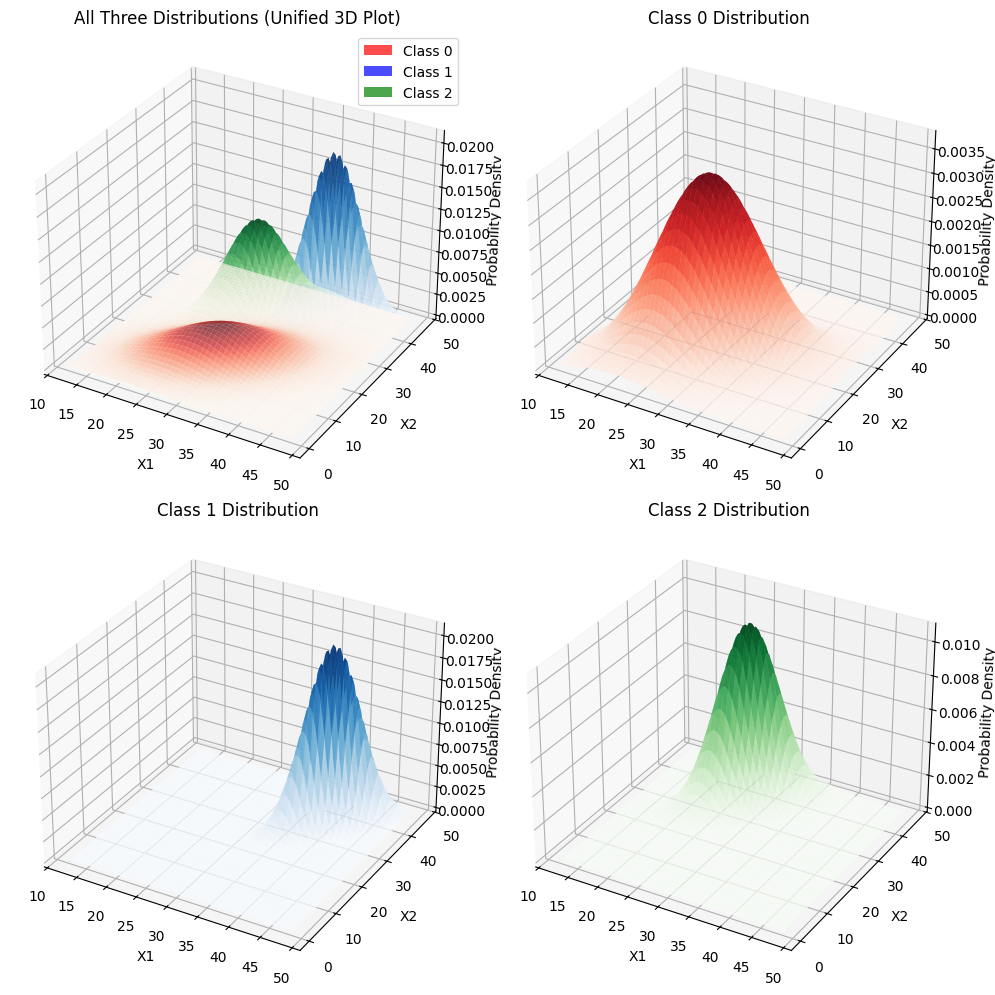

In [ ]:
#create grid for 3D plotting
#determine plot boundaries from data
all_data = np.vstack([class0, class1, class2])
x_min, x_max = all_data[:, 0].min() - 1, all_data[:, 0].max() + 1
y_min, y_max = all_data[:, 1].min() - 1, all_data[:, 1].max() + 1

#create mesh grid
x = np.linspace(x_min, x_max, 100)
y = np.linspace(y_min, y_max, 100)
X_grid, Y_grid = np.meshgrid(x, y)

#calculate PDF values for each distribution on the grid
print("Calculating PDF values for 3D plot...")

#initialize arrays
Z0 = np.zeros_like(X_grid)
Z1 = np.zeros_like(X_grid)
Z2 = np.zeros_like(X_grid)

#calculate PDF for each point
for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        Z0[i, j] = manual_bivariate_normal(X_grid[i, j], Y_grid[i, j], mean0, cov0)
        Z1[i, j] = manual_bivariate_normal(X_grid[i, j], Y_grid[i, j], mean1, cov1)
        Z2[i, j] = manual_bivariate_normal(X_grid[i, j], Y_grid[i, j], mean2, cov2)

print("PDF calculation complete!")

#unified 3D plot
fig = plt.figure(figsize=(10, 10))

#first subplot: All distributions together
ax1 = fig.add_subplot(221, projection='3d')

#plot each distribution
surf0 = ax1.plot_surface(X_grid, Y_grid, Z0, cmap='Reds', alpha=0.7, label='Class 0')
surf1 = ax1.plot_surface(X_grid, Y_grid, Z1, cmap='Blues', alpha=0.7, label='Class 1')
surf2 = ax1.plot_surface(X_grid, Y_grid, Z2, cmap='Greens', alpha=0.7, label='Class 2')

ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('Probability Density')
ax1.set_title('All Three Distributions (Unified 3D Plot)')

#create proxy artists for legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.7, label='Class 0'),
    Patch(facecolor='blue', alpha=0.7, label='Class 1'),
    Patch(facecolor='green', alpha=0.7, label='Class 2')
]
ax1.legend(handles=legend_elements)

#second subplot: Class 0 only
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot_surface(X_grid, Y_grid, Z0, cmap='Reds', alpha=0.8)
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_zlabel('Probability Density')
ax2.set_title('Class 0 Distribution')

#third subplot: Class 1 only
ax3 = fig.add_subplot(223, projection='3d')
ax3.plot_surface(X_grid, Y_grid, Z1, cmap='Blues', alpha=0.8)
ax3.set_xlabel('X1')
ax3.set_ylabel('X2')
ax3.set_zlabel('Probability Density')
ax3.set_title('Class 1 Distribution')

#fourth subplot: Class 2 only
ax4 = fig.add_subplot(224, projection='3d')
ax4.plot_surface(X_grid, Y_grid, Z2, cmap='Greens', alpha=0.8)
ax4.set_xlabel('X1')
ax4.set_ylabel('X2')
ax4.set_zlabel('Probability Density')
ax4.set_title('Class 2 Distribution')

plt.tight_layout()
plt.show()

## Task B (1/4)

In [3]:
#Β set up and data load

print("=== Μέρος Β: Parzen Windows Density Estimation ===")
print("\nLoading dataset2.csv...")

#load dataset2.csv
data2 = np.loadtxt('dataset2.csv', delimiter=',')
print(f"Dataset2 shape: {data2.shape}")
print(f"Number of samples: {len(data2)}")
print(f"Data range: [{data2.min():.3f}, {data2.max():.3f}]")
print(f"Mean: {data2.mean():.3f}, Std: {data2.std():.3f}")

def hypercube_kernel(u):
    """
    Hypercube (uniform) kernel: K(u) = 1 if |u| ≤ 0.5, else 0

    """
    return 1.0 if np.abs(u) <= 0.5 else 0.0

def gaussian_kernel(u):
    """
    Gaussian kernel: K(u) = (1/√(2π)) * exp(-0.5 * u²)
    """
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)


#Parzen Window Density Estimation Function
def parzen_density_estimate(x, data, h, kernel_func):
    """
    Manual Parzen window density estimation

    Parameters:
    x: point to estimate density at (scalar)
    data: array of samples
    h: bandwidth parameter
    kernel_func: kernel function to use

    Returns:
    Estimated density at point x
    """
    n = len(data)
    density = 0.0

    for xi in data:
        u = (x - xi) / h   # "/ h" because we use constant in kernel funcs
        density += kernel_func(u)

    return density / (n * h)


=== Μέρος Β: Parzen Windows Density Estimation ===

Loading dataset2.csv...
Dataset2 shape: (200,)
Number of samples: 200
Data range: [-5.397, 5.395]
Mean: 0.070, Std: 1.968


## Task B (2/4)


=== Verifying Distribution with Histogram ===
Theoretical: N(μ=1, σ²=4) → N(1, 2) [since σ=√4=2]


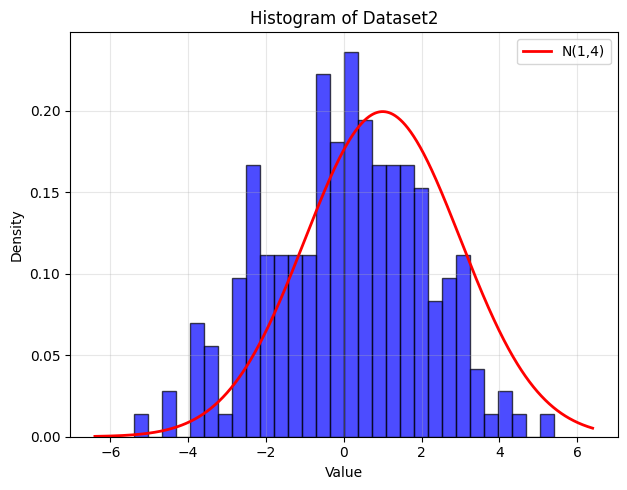


Shapiro-Wilk test for normality:
  Test statistic: 0.9952
  p-value: 0.7854
  Conclusion: Data appears normally distributed (fail to reject H0)


In [4]:
#histogram to verify Normal Distribution N(1,4)
print("\n=== Verifying Distribution with Histogram ===")
print("Theoretical: N(μ=1, σ²=4) → N(1, 2) [since σ=√4=2]")

plt.figure(figsize=(12, 5))

#histogram of data
plt.subplot(1, 2, 1)
plt.hist(data2, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
plt.title('Histogram of Dataset2')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)

#overlay theoretical normal distribution
x_range = np.linspace(data2.min() - 1, data2.max() + 1, 1000)
theoretical_pdf = (1/(2*np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x_range - 1)/2)**2)
plt.plot(x_range, theoretical_pdf, 'r-', linewidth=2, label='N(1,4)')
plt.legend()
plt.tight_layout()
plt.show()

# Statistical test for normality
from scipy.stats import shapiro
stat, p_value = shapiro(data2)
print(f"\nShapiro-Wilk test for normality:")
print(f"  Test statistic: {stat:.4f}")
print(f"  p-value: {p_value:.4f}")
if p_value > 0.05:
    print("Conclusion: Data appears normally distributed (fail to reject H0)")
else:
    print("Conclusion: Data does not appear normally distributed (reject H0)")

In [5]:
#true Normal Distribution PDF for Comparison

def true_normal_pdf(x, mu=1, sigma_sq=4):
    """
    True PDF of N(1,4) distribution
    """
    sigma = np.sqrt(sigma_sq)
    return (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)

## Task B (3/4)

In [6]:
#experiment with Different h Values
print("Testing h values from 0.1 to 10 with step 0.1")

#define h range
h_values = np.arange(0.1, 10.1, 0.1)
n_h = len(h_values)
print(f"Number of h values to test: {n_h}")

#initialize arrays to store results
mse_hypercube = np.zeros(n_h)
mse_gaussian = np.zeros(n_h)

#calculate MSE for all h values
print("\n Calculating MSE for all h values")

#we'll calculate MSE at multiple evaluation points
eval_points = np.linspace(data2.min(), data2.max(), 200)
true_at_eval = true_normal_pdf(eval_points)

for idx, h in enumerate(h_values):
    #calculate estimated densities at evaluation points
    hypercube_estimates = np.zeros_like(eval_points)
    gaussian_estimates = np.zeros_like(eval_points)

    for j, x in enumerate(eval_points):
        hypercube_estimates[j] = parzen_density_estimate(x, data2, h, hypercube_kernel)
        gaussian_estimates[j] = parzen_density_estimate(x, data2, h, gaussian_kernel)

    #calculate Mean Squared Error
    mse_hypercube[idx] = np.mean((hypercube_estimates - true_at_eval)**2)
    mse_gaussian[idx] = np.mean((gaussian_estimates - true_at_eval)**2)

    # Progress indicator
    if (idx + 1) % 20 == 0:
        print(f"  Processed {idx + 1}/{n_h} h values...")

print("MSE calculation complete!")

Testing h values from 0.1 to 10 with step 0.1
Number of h values to test: 100

 Calculating MSE for all h values
  Processed 20/100 h values...
  Processed 40/100 h values...
  Processed 60/100 h values...
  Processed 80/100 h values...
  Processed 100/100 h values...
MSE calculation complete!


## Task B (4/4)


=== Finding Optimal Bandwidth h ===
Results:
  Hypercube Kernel:
    Optimal h: 3.00
    Minimum MSE: 0.001081
  Gaussian Kernel:
    Optimal h: 0.90
    Minimum MSE: 0.001075

=== Plotting MSE vs Bandwidth h ===


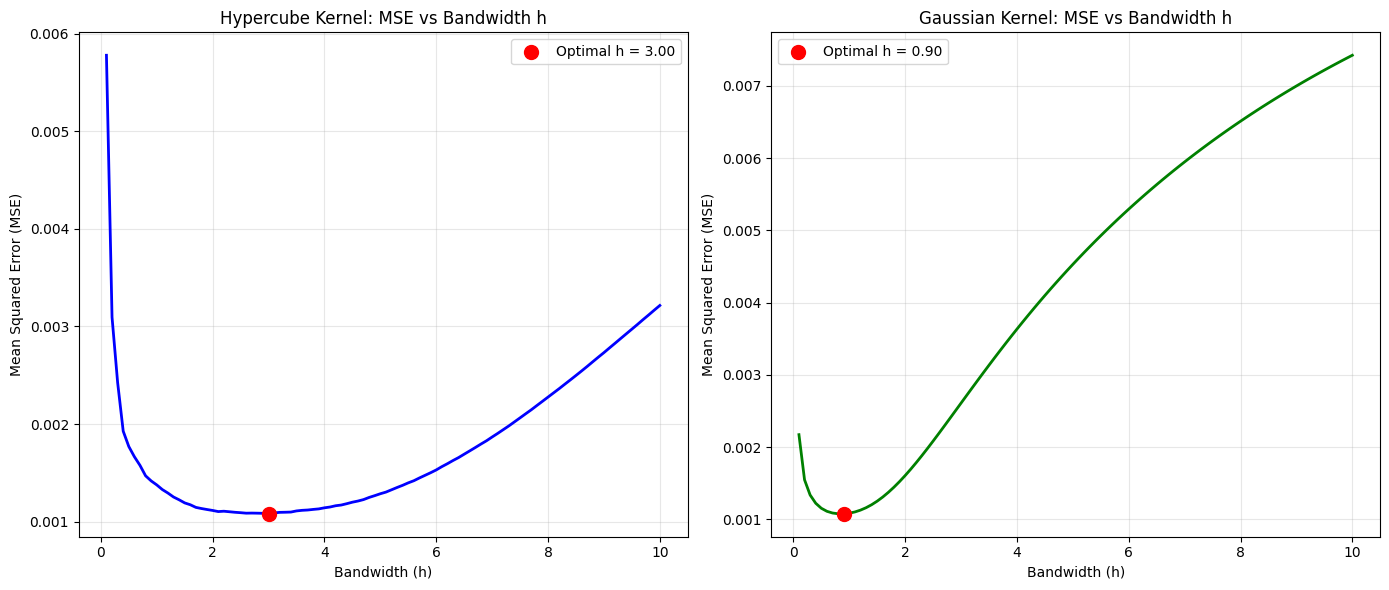

In [7]:
# Find Optimal h for Each Kernel
print("\n=== Finding Optimal Bandwidth h ===")

#find h with minimum MSE for each kernel
opt_idx_hypercube = np.argmin(mse_hypercube)
opt_idx_gaussian = np.argmin(mse_gaussian)

opt_h_hypercube = h_values[opt_idx_hypercube]
opt_h_gaussian = h_values[opt_idx_gaussian]

opt_mse_hypercube = mse_hypercube[opt_idx_hypercube]
opt_mse_gaussian = mse_gaussian[opt_idx_gaussian]

print("Results:")
print(f"  Hypercube Kernel:")
print(f"    Optimal h: {opt_h_hypercube:.2f}")
print(f"    Minimum MSE: {opt_mse_hypercube:.6f}")
print(f"  Gaussian Kernel:")
print(f"    Optimal h: {opt_h_gaussian:.2f}")
print(f"    Minimum MSE: {opt_mse_gaussian:.6f}")

# Plot MSE vs h for Both Kernels
print("\n=== Plotting MSE vs Bandwidth h ===")

plt.figure(figsize=(14, 6))

#plot for Hypercube Kernel
plt.subplot(1, 2, 1)
plt.plot(h_values, mse_hypercube, 'b-', linewidth=2)
plt.scatter([opt_h_hypercube], [opt_mse_hypercube], color='red', s=100, zorder=5,
           label=f'Optimal h = {opt_h_hypercube:.2f}')
plt.xlabel('Bandwidth (h)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Hypercube Kernel: MSE vs Bandwidth h')
plt.grid(True, alpha=0.3)
plt.legend()

#plot for Gaussian Kernel
plt.subplot(1, 2, 2)
plt.plot(h_values, mse_gaussian, 'g-', linewidth=2)
plt.scatter([opt_h_gaussian], [opt_mse_gaussian], color='red', s=100, zorder=5,
           label=f'Optimal h = {opt_h_gaussian:.2f}')
plt.xlabel('Bandwidth (h)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Gaussian Kernel: MSE vs Bandwidth h')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Task C (1/6)

In [ ]:
#Task C - KNN Classifier Setup
print("=== Μέρος Γ: K-Nearest Neighbors Classifier ===")
print("\nLoading training and test datasets...")

#load dataset3.csv for training
train_data = np.loadtxt('dataset3.csv', delimiter=',')
X_train = train_data[:, :2]  # Features
y_train = train_data[:, 2]   # Labels (0 or 1)

#load testset.csv for testing
test_data = np.loadtxt('testset.csv', delimiter=',')
X_test = test_data[:, :2]    # Features
y_test = test_data[:, 2]     # Labels (0 or 1)

print(f"Training set shape: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test set shape: {X_test.shape}, Labels: {y_test.shape}")
print(f"\nTraining class distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label, count in zip(unique_train, counts_train):
    print(f"  Class {int(label)}: {count} samples")
print(f"\nTest class distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label, count in zip(unique_test, counts_test):
    print(f"  Class {int(label)}: {count} samples")

=== Μέρος Γ: K-Nearest Neighbors Classifier ===

Loading training and test datasets...
Training set shape: (50, 2), Labels: (50,)
Test set shape: (50, 2), Labels: (50,)

Training class distribution:
  Class 0: 25 samples
  Class 1: 25 samples

Test class distribution:
  Class 0: 22 samples
  Class 1: 28 samples


## Task C (2/6)

In [ ]:
# Euclidean Distance Function
def euclidean_distance(x, train_data):
    """
    Manual Euclidean distance calculation
    x: single point (2D array)
    train_data: array of training points (n x 2)
    Returns: distances from x to all points in train_data
    """
    #ensure x is a row vector (1x2)
    if len(x.shape) == 1:
        x = x.reshape(1, -1)

    n_samples = train_data.shape[0]
    distances = np.zeros(n_samples)

    #calculating: sqrt((x1 - x2)² + (y1 - y2)²)
    for i in range(n_samples):
        diff = x - train_data[i]
        #square and sum
        squared_sum = 0
        for j in range(diff.shape[1]):
            squared_sum += diff[0, j] ** 2

        distances[i] = np.sqrt(squared_sum)

    return distances

## Task C (3/6)

In [ ]:
def neighbors(x, train_data, k):
    """
    Find k nearest neighbors of point x in train_data
    Returns: the actual POINTS from train_data
    """
    distances = euclidean_distance(x, train_data)
    n = len(distances)

    #create array of indices
    indices = list(range(n))

    #find minimum and swap to front
    for i in range(n):
        #find minimum element in unsorted part
        min_idx = i
        for j in range(i + 1, n):
            if distances[indices[j]] < distances[indices[min_idx]]:
                min_idx = j

        #swap the found minimum with first element of unsorted part
        indices[i], indices[min_idx] = indices[min_idx], indices[i]

    #get the points corresponding to k smallest distances
    k_nearest_points = train_data[indices[:k]]

    return k_nearest_points

## Task C (4/6)

In [ ]:
# Predict Function with Probabilities - UPDATED for neighbors returning points
def predict(test_data, train_data, train_labels, k):
    """
    Predict class probabilities for test points

    """
    n_test = test_data.shape[0]
    prob_class0 = np.zeros(n_test)
    prob_class1 = np.zeros(n_test)

    for i in range(n_test):
        x = test_data[i:i+1, :]  # Current test point

        #find k nearest neighbors (returns POINTS)
        neighbor_points = neighbors(x, train_data, k)

        #now we need to find which training points these are
        #we have to match points to get their labels

        #count class occurrences among neighbors
        count_0 = 0
        count_1 = 0

        for neighbor_point in neighbor_points:
            #find the index of this neighbor point in training data
            for j in range(len(train_data)):
                if np.array_equal(train_data[j], neighbor_point):
                    #found matching point, check its label
                    if train_labels[j] == 0:
                        count_0 += 1
                    else:
                        count_1 += 1
                    break  #move to next neighbor point

        # Calculate probabilities (must sum to 1)
        total = count_0 + count_1
        if total > 0:
            prob_class0[i] = count_0 / total
            prob_class1[i] = count_1 / total
        else:
            prob_class0[i] = 0.5
            prob_class1[i] = 0.5

    return prob_class0, prob_class1

# Test the predict function
print("=== Testing Predict Function ===")
k_test = 5
prob_0, prob_1 = predict(X_test[:5], X_train, y_train, k_test)

print(f"Predictions for first 5 test points (k={k_test}):")
for i in range(5):
    print(f"\nTest point {i}: {X_test[i]}")
    print(f"  True class: {y_test[i]}")
    print(f"  P(class=0): {prob_0[i]:.4f}")
    print(f"  P(class=1): {prob_1[i]:.4f}")
    print(f"  Sum: {prob_0[i] + prob_1[i]:.4f} (should be 1.0)")

    # Make prediction based on higher probability
    pred_class = 0 if prob_0[i] > prob_1[i] else 1
    print(f"  Predicted class: {pred_class}")
    print(f"  Correct: {pred_class == y_test[i]}")

=== Testing Predict Function ===
Predictions for first 5 test points (k=5):

Test point 0: [ 5.59219531 35.69991939]
  True class: 1.0
  P(class=0): 0.6000
  P(class=1): 0.4000
  Sum: 1.0000 (should be 1.0)
  Predicted class: 0
  Correct: False

Test point 1: [13.33362151 40.28918047]
  True class: 0.0
  P(class=0): 1.0000
  P(class=1): 0.0000
  Sum: 1.0000 (should be 1.0)
  Predicted class: 0
  Correct: True

Test point 2: [10.73324978 28.25624275]
  True class: 1.0
  P(class=0): 0.2000
  P(class=1): 0.8000
  Sum: 1.0000 (should be 1.0)
  Predicted class: 1
  Correct: True

Test point 3: [ 6.2525288  25.73650931]
  True class: 1.0
  P(class=0): 0.0000
  P(class=1): 1.0000
  Sum: 1.0000 (should be 1.0)
  Predicted class: 1
  Correct: True

Test point 4: [12.30884532 29.03770601]
  True class: 1.0
  P(class=0): 0.4000
  P(class=1): 0.6000
  Sum: 1.0000 (should be 1.0)
  Predicted class: 1
  Correct: True


## Task C (5/6)

In [ ]:
# Find Optimal k Value (1 to 30)
print("Finding Optimal k Value")
print("Testing k from 1 to 30")

k_values = list(range(1, 31))
accuracies = []

for k in k_values:
    #predict for all test points
    prob_0, prob_1 = predict(X_test, X_train, y_train, k)

    #make predictions (class with higher probability)
    predictions = np.zeros(len(X_test))
    for i in range(len(X_test)):
        predictions[i] = 0 if prob_0[i] > prob_1[i] else 1

    #calculate accuracy
    correct = np.sum(predictions == y_test)
    accuracy = correct / len(y_test)
    accuracies.append(accuracy)

    #progress indicator
    if k % 5 == 0:
        print(f"  k={k}: accuracy = {accuracy:.4f}")

#find best k
best_idx = np.argmax(accuracies)
best_k = k_values[best_idx]
best_accuracy = accuracies[best_idx]

print(f"\nResults")
print(f"Best k: {best_k}")
print(f"Best accuracy: {best_accuracy:.4f} ({best_accuracy*100:.1f}%)")
print(f"\nTop 5 k values:")

#sort by accuracy
sorted_indices = np.argsort(accuracies)[::-1]  # Descending
for i in range(5):
    idx = sorted_indices[i]
    print(f"  k={k_values[idx]}: {accuracies[idx]:.4f}")

Finding Optimal k Value
Testing k from 1 to 30
  k=5: accuracy = 0.6200
  k=10: accuracy = 0.7000
  k=15: accuracy = 0.7200
  k=20: accuracy = 0.6600
  k=25: accuracy = 0.6600
  k=30: accuracy = 0.6800

Results
Best k: 16
Best accuracy: 0.7600 (76.0%)

Top 5 k values:
  k=16: 0.7600
  k=11: 0.7400
  k=15: 0.7200
  k=14: 0.7200
  k=18: 0.7200


## Task C (6/6)

Plotting Accuracy vs k


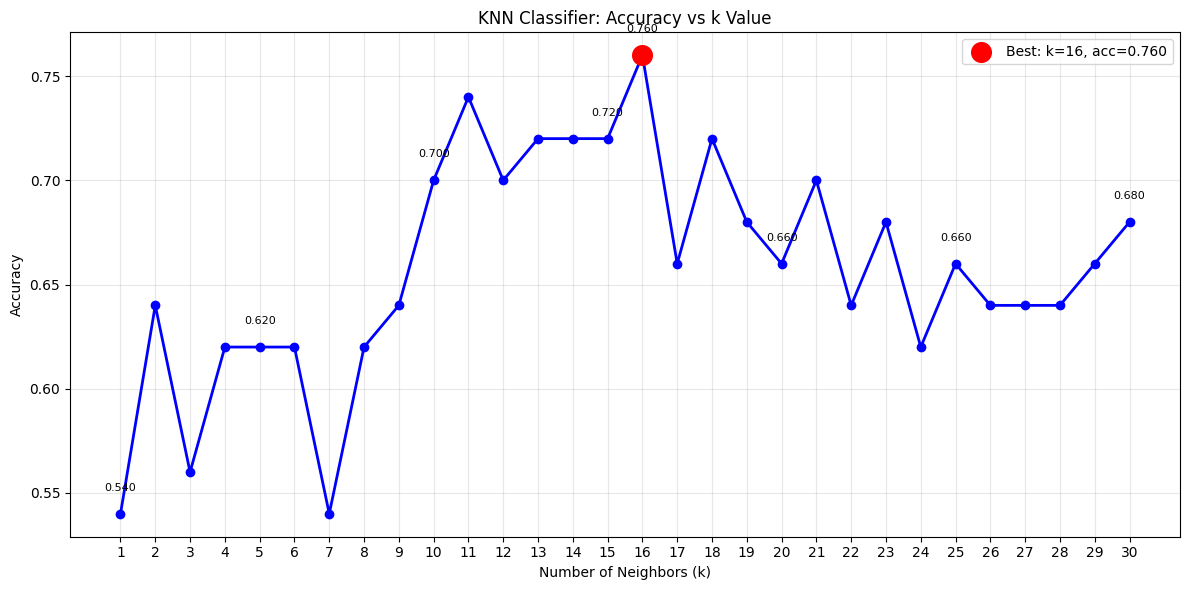

In [ ]:
# Plot Accuracy vs k
print("Plotting Accuracy vs k")

plt.figure(figsize=(12, 6))

#plot accuracy curve
plt.plot(k_values, accuracies, 'b-', linewidth=2, marker='o', markersize=6)
plt.scatter([best_k], [best_accuracy], color='red', s=200, zorder=5,
           label=f'Best: k={best_k}, acc={best_accuracy:.3f}')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN Classifier: Accuracy vs k Value')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()

#add accuracy values on plot
for k, acc in zip(k_values, accuracies):
    if k in [1, 5, 10, 15, 20, 25, 30] or k == best_k:
        plt.text(k, acc + 0.01, f'{acc:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Decision Boundaries Visualization
print("Visualizing Decision Boundaries")
print(f"Using best k={best_k}")

#create mesh grid for decision boundaries
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

#predict for each point in mesh
mesh_points = np.c_[xx.ravel(), yy.ravel()]
Z_probs = []

#process in batches to avoid memory issues
batch_size = 100
n_batches = int(np.ceil(len(mesh_points) / batch_size))

for i in range(n_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, len(mesh_points))
    batch_points = mesh_points[start_idx:end_idx]

    prob_0_batch, prob_1_batch = predict(batch_points, X_train, y_train, best_k)

    #store prediction (class with higher probability)
    for j in range(len(batch_points)):
        if prob_0_batch[j] > prob_1_batch[j]:
            Z_probs.append(0)
        else:
            Z_probs.append(1)

    #progress indicator
    if (i + 1) % 20 == 0:
        print(f"  Processed {i + 1}/{n_batches} batches...")

Z = np.array(Z_probs).reshape(xx.shape)

Visualizing Decision Boundaries
Using best k=16
  Processed 20/400 batches...
  Processed 40/400 batches...
  Processed 60/400 batches...
  Processed 80/400 batches...
  Processed 100/400 batches...
  Processed 120/400 batches...
  Processed 140/400 batches...
  Processed 160/400 batches...
  Processed 180/400 batches...
  Processed 200/400 batches...
  Processed 220/400 batches...
  Processed 240/400 batches...
  Processed 260/400 batches...
  Processed 280/400 batches...
  Processed 300/400 batches...
  Processed 320/400 batches...
  Processed 340/400 batches...
  Processed 360/400 batches...
  Processed 380/400 batches...
  Processed 400/400 batches...


Plotting Decision Boundaries


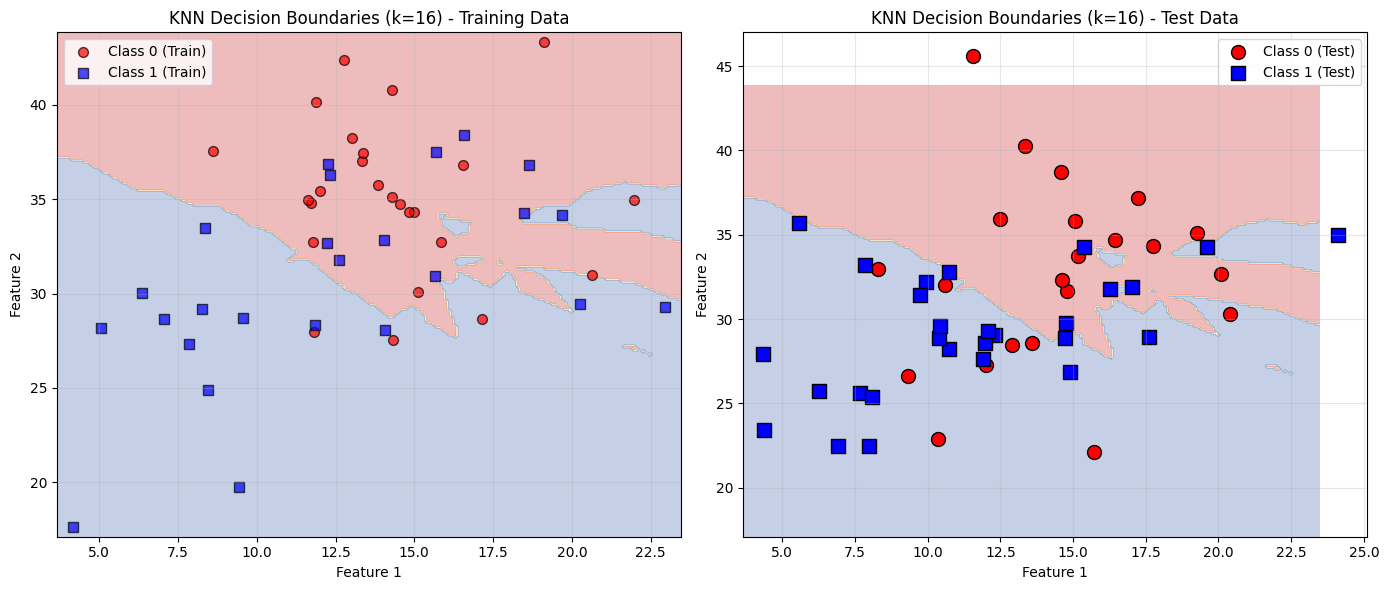

In [ ]:
# Plot Decision Boundaries and Data
print("Plotting Decision Boundaries")

plt.figure(figsize=(14, 6))

# plot 1: Decision boundaries with training data
plt.subplot(1, 2, 1)
#plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
#plot training data
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c='red', marker='o', edgecolor='black',
            s=50, label='Class 0 (Train)', alpha=0.7)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c='blue', marker='s', edgecolor='black',
            s=50, label='Class 1 (Train)', alpha=0.7)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'KNN Decision Boundaries (k={best_k}) - Training Data')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# plot 2: Decision boundaries with test data
plt.subplot(1, 2, 2)
#plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
#plot test data
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
            c='red', marker='o', edgecolor='black',
            s=100, label='Class 0 (Test)', alpha=1.0)
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
            c='blue', marker='s', edgecolor='black',
            s=100, label='Class 1 (Test)', alpha=1.0)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'KNN Decision Boundaries (k={best_k}) - Test Data')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()